# BinWaves example in Cantabria (Propagation)

**In this notebook**: 
<br><br>
Here is where the construction of the library of pre-run cases for all the monochromatic wave systems is made.
<br><br>
Steps:
- Generates wave conditions for all given frequencies and directions.
- Generates SWAN cases and runs them.
- Extracts SWAN cases and saves output.
- Plots the library for all the cases and some larger example ones.

## Generate computational bathymetry

In [1]:
import xarray as xr

bathy = -(
    xr.open_dataset("outputs/carolinas_gebco_utm18_cy_cx.nc")
    .rename({"cx": "lon", "cy": "lat"})
    .transpose("lat", "lon")
    .isel(lon=slice(0, 10000, 500), lat=slice(0, 10000, 500))
    .sortby("lat", ascending=False)
    .elevation
)
bathy

<xarray.DataArray 'elevation' (lat: 14, lon: 18)> Size: 2kB
array([[            nan, -5.84982628e+02, -1.04310155e+03,
        -7.92158349e+02, -4.58576943e+02, -3.01564286e+02,
        -1.46209113e+02, -1.21607740e+02, -1.13234145e+02,
        -4.73223627e+01, -2.10617650e+01,  3.31398934e+00,
         1.88071041e+01,  2.90000000e+01,  1.50594112e+02,
         2.34587540e+03,  2.96050346e+03,             nan],
       [            nan, -1.23486829e+03, -5.66821114e+02,
        -2.77799968e+02, -2.54960482e+02, -2.41946921e+02,
        -1.61074056e+02, -1.47320476e+02, -8.75379634e+01,
        -3.13383875e+01, -1.00000000e+01, -1.42306250e+01,
         1.51900735e+01,  3.62739934e+01,  1.23762475e+03,
         2.51606705e+03,  3.06080384e+03,             nan],
       [            nan, -3.84031859e+02, -3.01880140e+02,
        -2.55404286e+02, -2.13710106e+02, -1.94080363e+02,
        -1.41565609e+02, -7.50543895e+01, -5.30699874e+01,
        -2.75681179e+01, -1.07156791e+01,  2.47177730e+00,
         1.00000000e+00,  3.08205662e+01,  1.59349464e+03,
         2.60635798e+03,  3.38931126e+03,             nan],
       [            nan, -2.63251896e+02, -2.85072198e+02,
        -1.89503914e+02, -1.78474940e+02, -1.31381817e+02,
...
         3.07629309e+03,  3.98166916e+03,  4.49669984e+03,
         4.83977930e+03,  5.13409377e+03,  5.28200334e+03],
       [            nan, -1.42970944e+01,  3.00000000e+00,
         1.60000000e+01,  3.30000000e+01,  1.23582616e+02,
         4.36835569e+02,  6.06998799e+02,  6.30894212e+02,
         8.45989720e+02,  2.33863429e+03,  2.63179923e+03,
         2.76896733e+03,  3.35460925e+03,  4.43942885e+03,
         4.96516134e+03,  5.16211663e+03,  5.32215851e+03],
       [            nan, -1.72249569e+01,  1.40000000e+01,
         2.90000000e+01,  4.45587438e+01,  4.34751795e+02,
         5.10289028e+02,  6.93089661e+02,  7.94556722e+02,
         1.04425187e+03,  2.60527049e+03,  2.82494478e+03,
         3.14490852e+03,  3.06494205e+03,  3.97847507e+03,
         5.04109167e+03,  5.18133793e+03,  5.33925991e+03],
       [            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan]])
Coordinates:
  * lon      (lon) float64 144B -1.688e+05 -1.188e+05 ... 6.312e+05 6.812e+05
  * lat      (lat) float64 112B 4.08e+06 4.03e+06 3.98e+06 ... 3.48e+06 3.43e+06
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

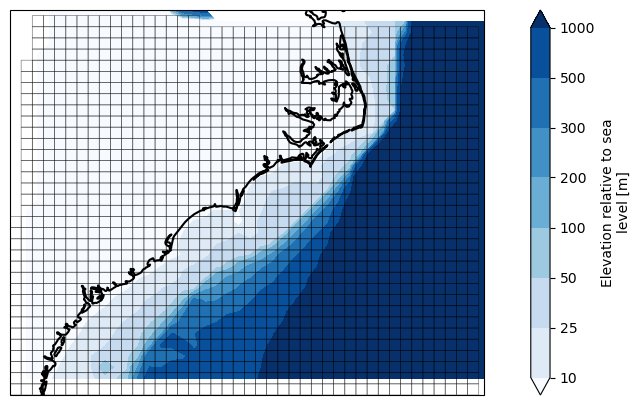

In [3]:
from utils.plotting import plot_selected_bathy

plot_selected_bathy(bathy=bathy)

In [3]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

fixed_parameters = generate_grid_parameters(bathy_data=bathy)
fixed_parameters

{'xpc': -168833,
 'ypc': 3429832,
 'alpc': 0,
 'xlenc': 850000,
 'ylenc': 650000,
 'mxc': 17,
 'myc': 13,
 'xpinp': np.float64(-168833.74928423273),
 'ypinp': np.float64(3429832.821336043),
 'alpinp': 0,
 'mxinp': 17,
 'myinp': 13,
 'dxinp': np.float64(50000.0),
 'dyinp': np.float64(50000.0)}

## Create SWAN cases

In [4]:
from bluemath_tk.waves.binwaves import generate_swan_cases
from utils.wrapper import example_directions, example_frequencies

# Generate swan model parameters
example_directions = example_directions
swan_cases_df = (
    generate_swan_cases(
        directions_array=example_directions,
        frequencies_array=example_frequencies,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df

,dir,freq,hs,tp,spr,gamma
0,7.5,0.035000,1.0,28.5714,2.0,50.0
1,7.5,0.038500,1.0,25.9740,2.0,50.0
2,7.5,0.042350,1.0,23.6128,2.0,50.0
3,7.5,0.046585,1.0,21.4661,2.0,50.0
4,7.5,0.051243,1.0,19.5147,2.0,50.0
...,...,...,...,...,...,...
691,352.5,0.344741,0.1,2.9007,2.0,50.0
692,352.5,0.379215,0.1,2.6370,2.0,50.0
693,352.5,0.417136,0.1,2.3973,2.0,50.0
694,352.5,0.458850,0.1,2.1794,2.0,50.0


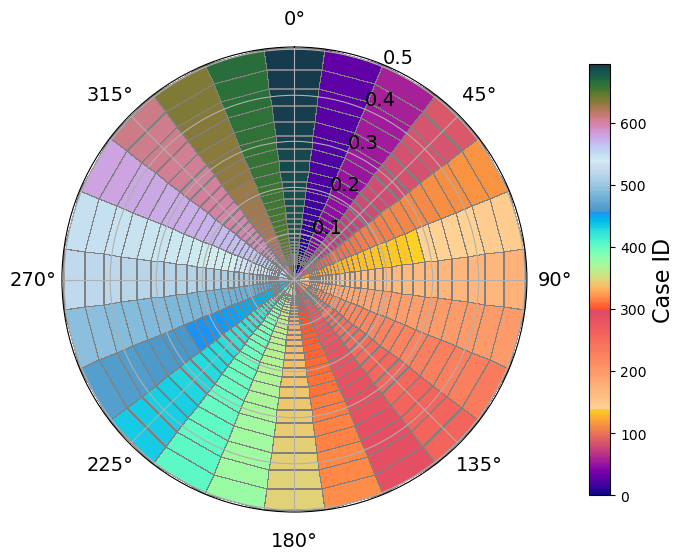

In [5]:
import numpy as np
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid

plot_selected_cases_grid(
    frequencies=np.array(example_frequencies),
    directions=np.array(example_directions),
    figsize=(8, 8),
)

## Build and run SWAN cases

In [6]:
import os
from utils.wrapper import BinWavesWrapper

# Define the input templates and output directory for the wrapper

templates_dir = os.path.join(os.getcwd(), "templates")
templates_name = ["INPUT"]
output_dir = os.path.join(os.getcwd(), "CAN_cases")

# Create an instance of the SWAN model wrapper

swan_wrapper = BinWavesWrapper(
    templates_dir=templates_dir,
    templates_name=templates_name,
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_dataarray=bathy,
)

Dataset coordinates: Coordinates:
  * lon      (lon) float64 144B -1.688e+05 -1.188e+05 ... 6.312e+05 6.812e+05
  * lat      (lat) float64 112B 4.08e+06 4.03e+06 3.98e+06 ... 3.48e+06 3.43e+06
Dataset dimensions: ('lat', 'lon')
Dataset variables: No variables


2025-05-08 12:13:44,763 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-05-08 12:13:44,764 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-05-08 12:13:44,764 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-05-08 12:13:44,764 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-05-08 12:13:44,765 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-05-08 12:13:44,765 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [7]:
# Build the input files

swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join(output_dir, "swan_cases.csv"), index=False)

# Set the cases directories from the output directory
# Execute if the cases are already built

# swan_wrapper.set_cases_dirs_from_output_dir()

In [8]:
# Run the model

swan_wrapper.run_cases_in_background(launcher="/software/geocean/swan/swan_serial.exe", num_workers=10)

In [9]:
# Monitor running cases

swan_wrapper.monitor_cases()

,Case,Percentage
0,0000,100 %
1,0001,100 %
2,0002,100 %
3,0003,100 %
4,0004,100 %
...,...,...
691,0691,100 %
692,0692,100 %
693,0693,100 %
694,0694,100 %


In [10]:
# Post-process the output files

cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

2025-05-08 12:15:07,455 - BinWavesWrapper - WARNING - Output postprocessed file already exists. Skipping postprocessing.


<xarray.Dataset> Size: 2MB
Dimensions:   (case_num: 696, Yp: 14, Xp: 18)
Coordinates:
  * Xp        (Xp) float32 72B -1.688e+05 -1.188e+05 ... 6.312e+05 6.812e+05
  * Yp        (Yp) float32 56B 3.43e+06 3.48e+06 3.53e+06 ... 4.03e+06 4.08e+06
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
Data variables:
    Hsig      (case_num, Yp, Xp) float32 702kB ...
    Tm02      (case_num, Yp, Xp) float32 702kB ...
    Dir       (case_num, Yp, Xp) float32 702kB ...

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/bluemath_tk/core/operations.py:342: RuntimeWarning: invalid value encountered in multiply
  x_rad = x_deg * np.pi / 180
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


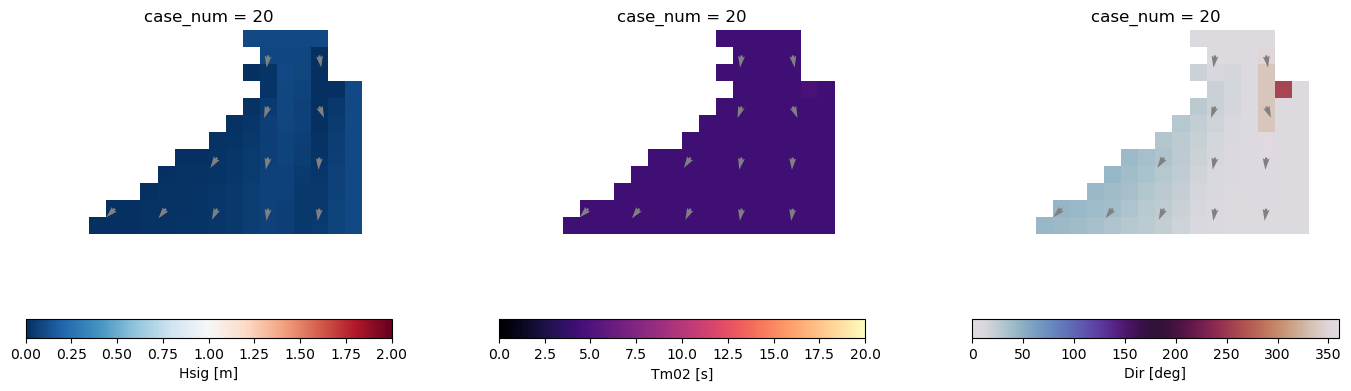

In [11]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=20),
)

## Plot ALL pre-run cases

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


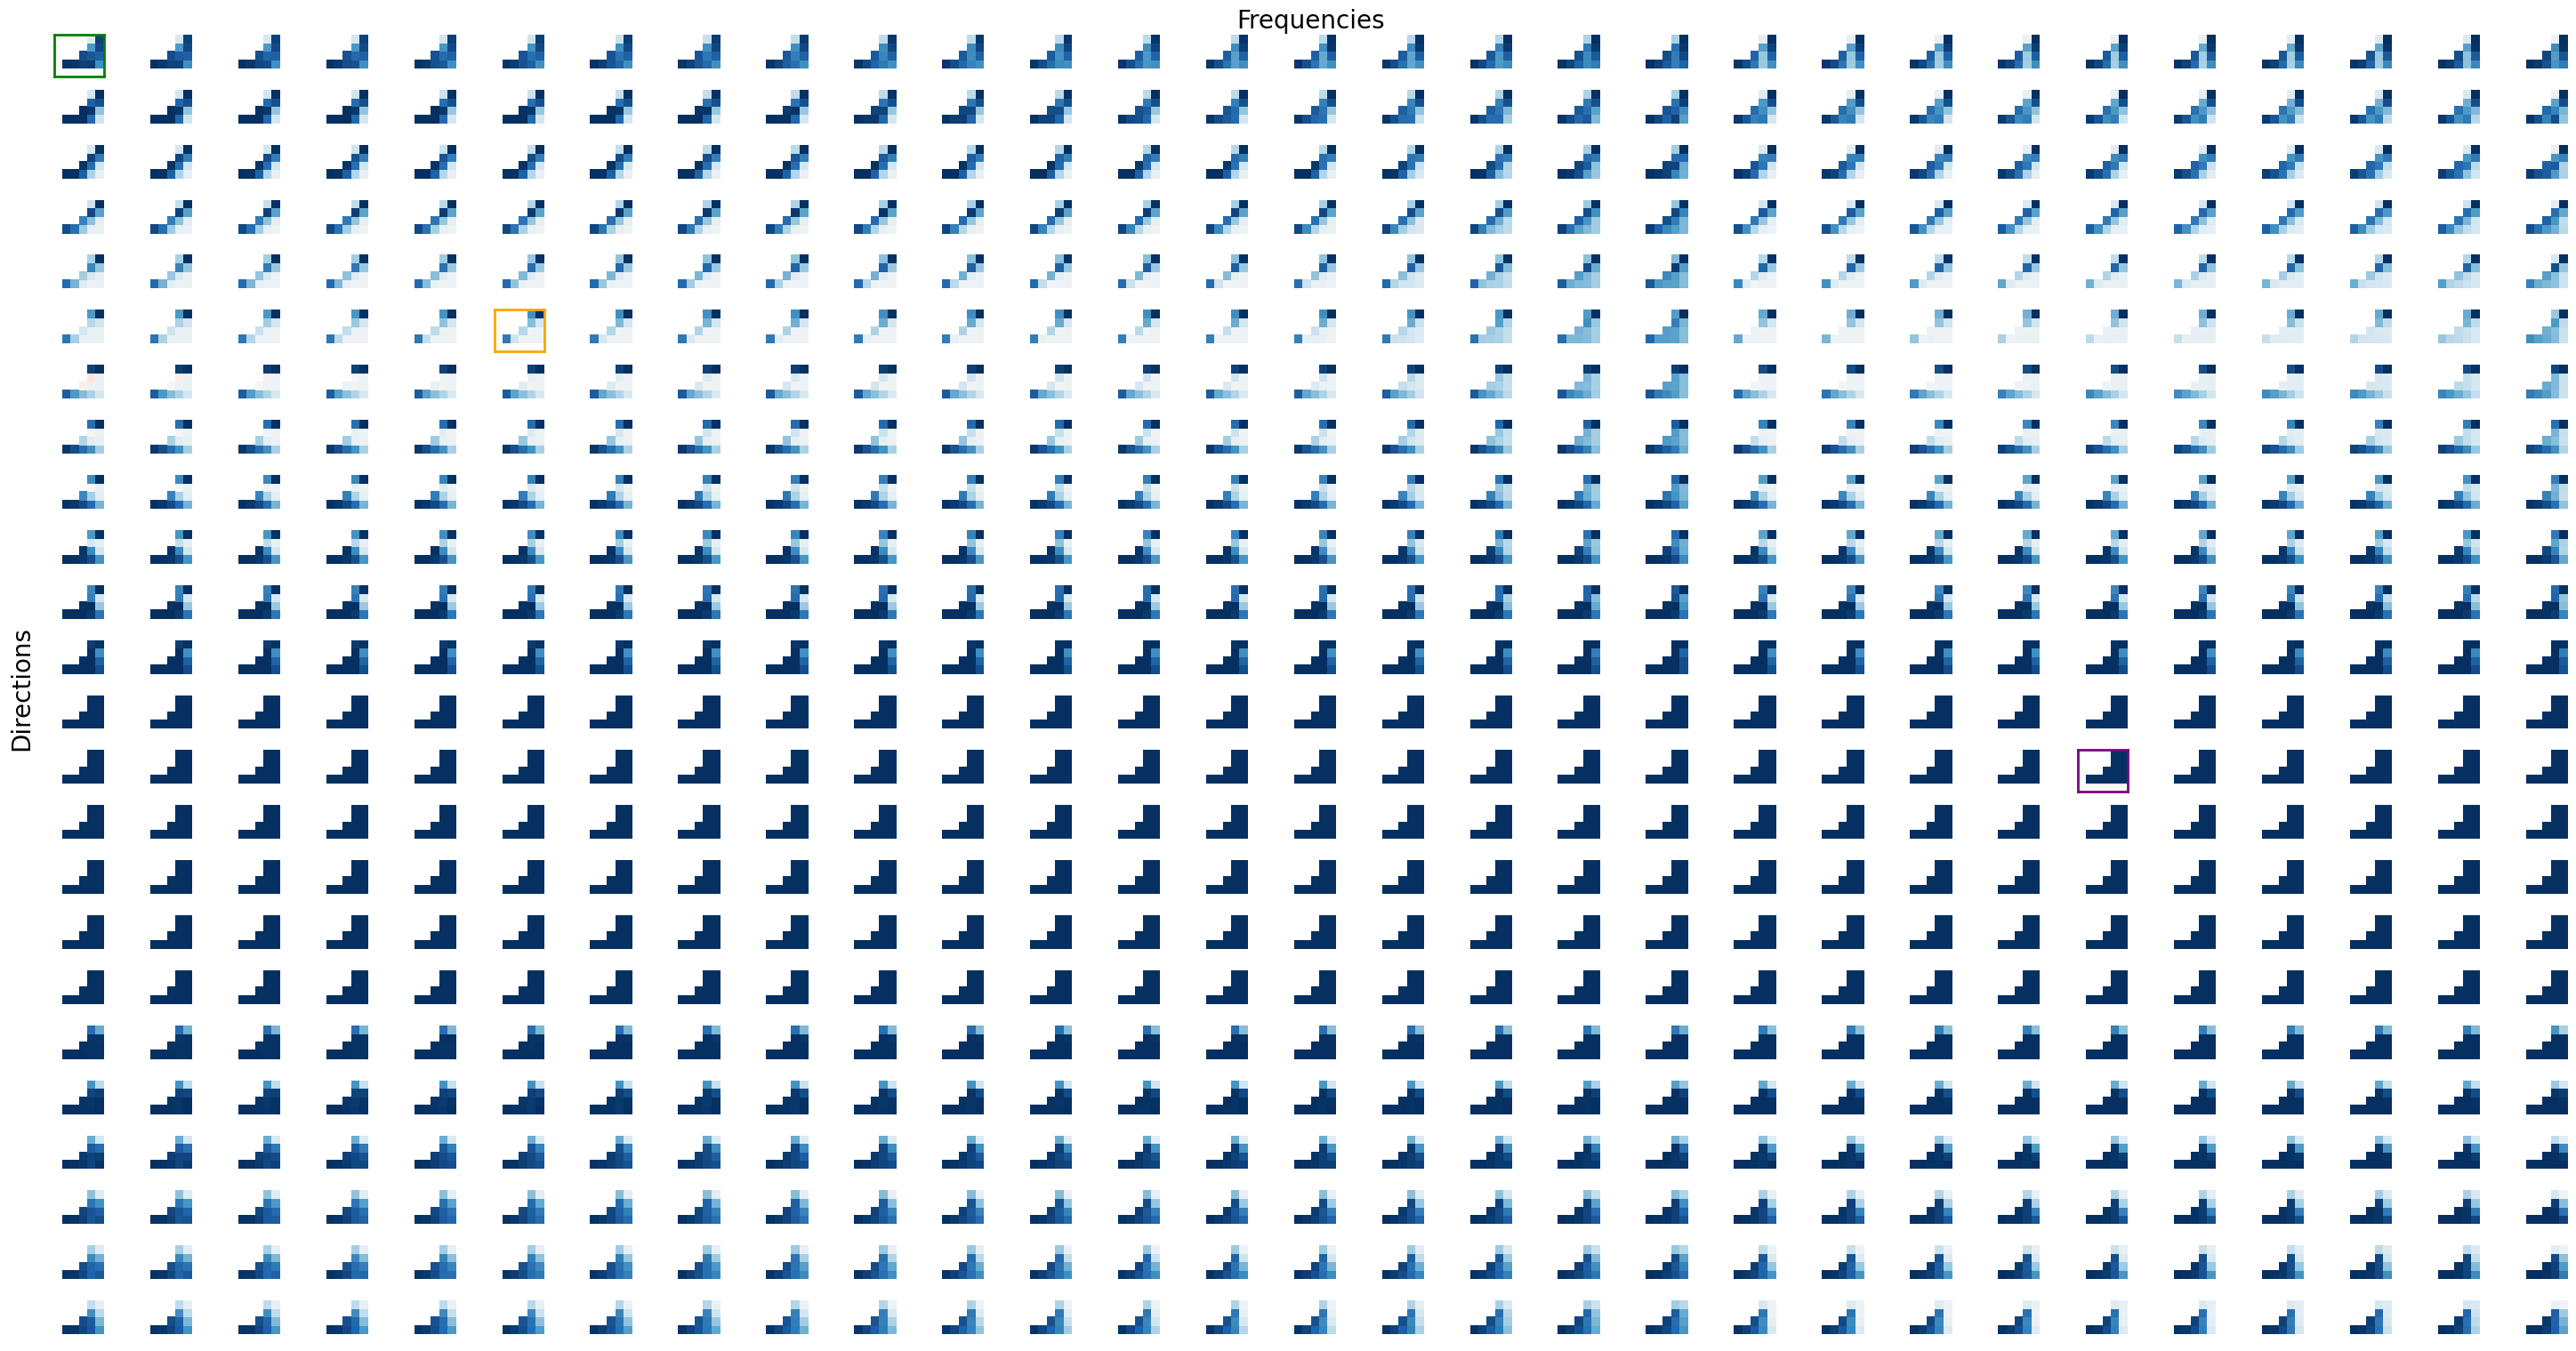

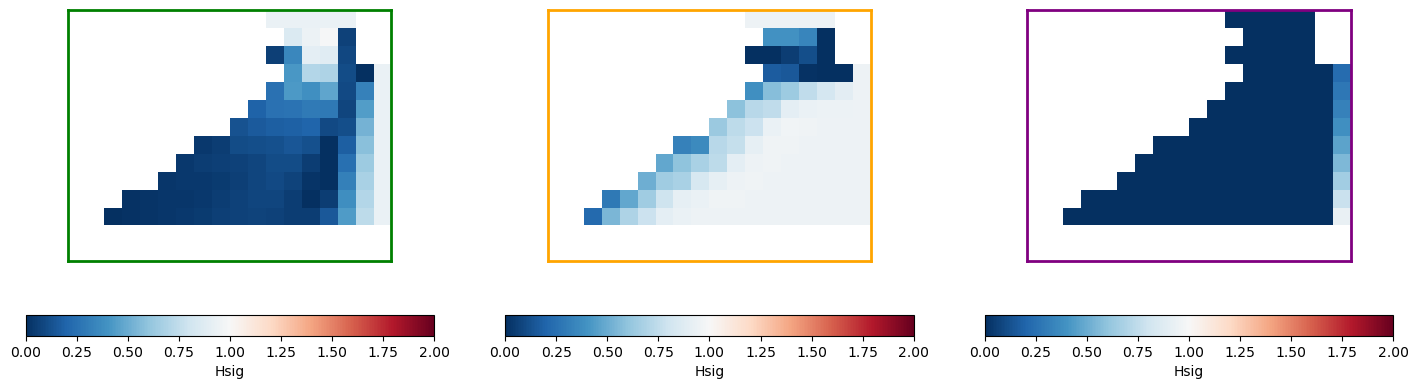

In [15]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 150, 400],
    num_directions=len(example_directions),
    num_frequencies=len(example_frequencies),
)

## Extract kp coefficients

In [ ]:
# ps aux | grep python
# pkill -f "python"

In [16]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

<xarray.DataArray 'efth' (case_num: 696, freq: 31, dir: 24)> Size: 4MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 4.72344319e-04, 1.45529354e-03, ...,
         0.00000000e+00, 1.04347051e-06, 3.47823504e-07],
        [0.00000000e+00, 1.39372878e-03, 3.44380051e-03, ...,
         0.00000000e+00, 2.08694102e-06, 6.95647008e-07],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 7.78721747e-04, 1.92384206e-03, ...,
         0.00000000e+00, 1.49754182e-06, 4.99180607e-07],
...
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.61112088e-02, 5.47752557e-03, 2.53174027e-04, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.15197923e-03, 3.53388747e-04, 1.31861473e-05, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.46275760e-03, 1.27184964e-03, 4.18821455e-05, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]],
      shape=(696, 31, 24))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    time      datetime64[ns] 8B 2025-05-08T12:17:00

In [19]:
# kp_coefficients.to_dataset(name="kps").drop(["time", "lat", "lon"]).assign_coords(
#     utm_x=(("site"), swan_wrapper.locations[:, 0]),
#     utm_y=(("site"), swan_wrapper.locations[:, 1]),
# ).to_netcdf("outputs/kp_coefficients.nc")
# If you only need to drop 'time':
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    utm_x=(("site"), swan_wrapper.locations[:, 0]),
    utm_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients.nc")

/tmp/ipykernel_2006776/4113431545.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
